<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Sleep Quality and Disorders Using LSTM Models on Wearable Sensor Data**
<hr>





**Dataset:** [Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)





# Setting up Kaggle API for getting the dataset



In [ ]:
! pip install kaggle -q
! mkdir ~/.kaggle                         
! cp kaggle.json ~/.kaggle/               
! chmod 600 ~/.kaggle/kaggle.json         


**Put the name of the dataset that you want to use and then unzip the dataset**

In [ ]:
! kaggle datasets download -d uom190346a/sleep-health-and-lifestyle-dataset  


Dataset URL: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
License(s): CC0-1.0
  0% 0.00/2.54k [00:00<?, ?B/s]
100% 2.54k/2.54k [00:00<00:00, 9.24MB/s]


In [ ]:
! unzip -q sleep-health-and-lifestyle-dataset.zip  
! ls *.csv


Sleep_health_and_lifestyle_dataset.csv


# Importing Necessary Libraries
<hr>


In [ ]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np                        
import pandas as pd                       
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Bidirectional,
    GRU, Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D,
    Input, Add, Multiply, Attention, LayerNormalization,
    MultiHeadAttention, Reshape
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import model_from_json

# Imbalance
from imblearn.over_sampling import SMOTE

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: []


In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')  


df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')  
df = df.reset_index(drop=True)

print(f"Dataset shape after cleaning: {df.shape}")
df.head(5), df.shape     


Dataset shape after cleaning: (374, 13)


(   Person ID Gender  Age            Occupation  Sleep Duration  \
 0          1   Male   27     Software Engineer             6.1   
 1          2   Male   28                Doctor             6.2   
 2          3   Male   28                Doctor             6.2   
 3          4   Male   28  Sales Representative             5.9   
 4          5   Male   28  Sales Representative             5.9   
 
    Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
 0                 6                       42             6   Overweight   
 1                 6                       60             8       Normal   
 2                 6                       60             8       Normal   
 3                 4                       30             8        Obese   
 4                 4                       30             8        Obese   
 
   Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
 0         126/83          77         4200           None  
 1         125/80 

# Exploratory Data Analysis
<hr>


In [ ]:
print("Null values present in the file:", df.isna().sum().sum())
print("\nBasic information about the dataframe:")
df.info()

df.describe()


Null values present in the file: 0

Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: fl

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:

sleep_disorders = {     
    0: 'Insomnia',
    1: 'None',
    2: 'Sleep Apnea'
}
print("Sleep disorder classes:", sleep_disorders)
print("\nUnique values in Sleep Disorder column (NaN-safe):")
print(df['Sleep Disorder'].value_counts(dropna=False))


Sleep disorder classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

Unique values in Sleep Disorder column (NaN-safe):
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## Number of records present in dataset corresponding to each sleep disorder

In [ ]:
count_disorders = df['Sleep Disorder'].value_counts().to_frame()
count_disorders.columns = ['count']
count_disorders['disorder name'] = count_disorders.index
count_disorders


,count,disorder name
Sleep Disorder,,
None,219,None
Sleep Apnea,78,Sleep Apnea
Insomnia,77,Insomnia


## Distribution of records by Gender and BMI Category

In [ ]:
count_gender = df.groupby('Gender')['Sleep Disorder'].count().to_frame()
count_gender.columns = ['count']

count_bmi = df.groupby('BMI Category')['Sleep Disorder'].count().to_frame()
count_bmi.columns = ['count']

print("By Gender:")
print(count_gender)
print("\nBy BMI Category:")
print(count_bmi)


By Gender:
        count
Gender       
Female    185
Male      189

By BMI Category:
               count
BMI Category        
Normal           195
Normal Weight     21
Obese             10
Overweight       148


## Sleep Disorder Class Distribution (Bar Chart)



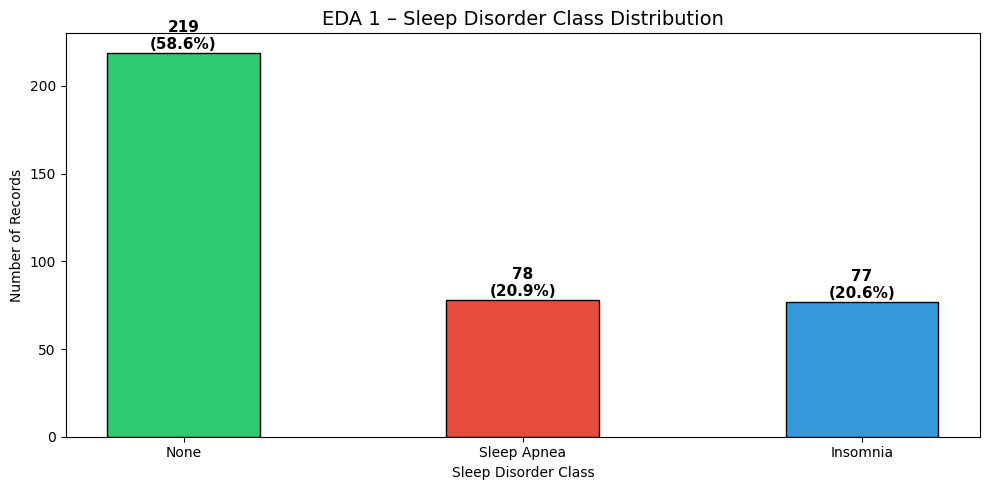

Class counts:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77


In [ ]:

import matplotlib.pyplot as plt, numpy as np

disorder_counts = df['Sleep Disorder'].value_counts()
colors_eda1 = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(disorder_counts.index, disorder_counts.values,
              color=colors_eda1, edgecolor='black', width=0.45)
for bar, cnt in zip(bars, disorder_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('EDA 1 – Sleep Disorder Class Distribution', fontsize=14)
ax.set_xlabel('Sleep Disorder Class'); ax.set_ylabel('Number of Records')
plt.tight_layout(); plt.show()
print("Class counts:")
print(disorder_counts.to_string())


##  Gender & BMI Category Distribution (Pie Charts)



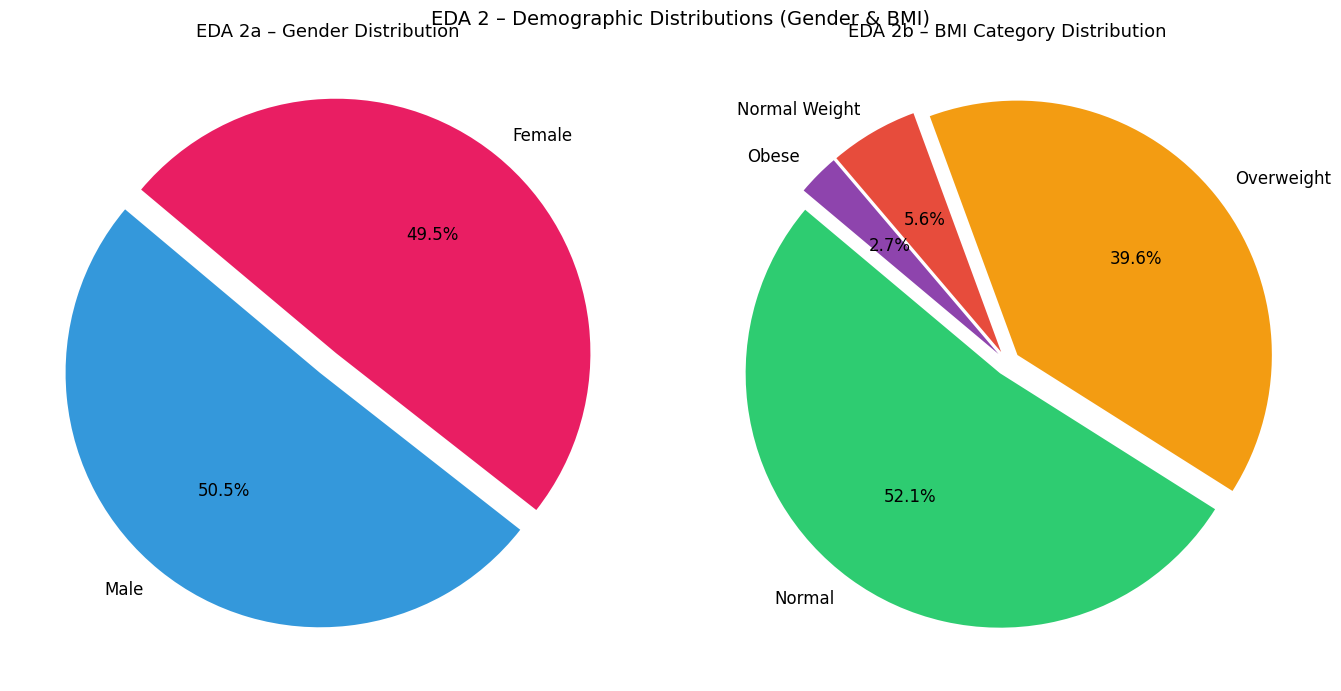

Gender
Male      189
Female    185
Name: count, dtype: int64

 BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Gender
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#3498db','#e91e63'],
            explode=[0.05]*len(gender_counts), startangle=140,
            textprops={'fontsize': 12})
axes[0].set_title('EDA 2a – Gender Distribution', fontsize=13)

# BMI Category
bmi_counts = df['BMI Category'].value_counts()
colors_bmi = ['#2ecc71','#f39c12','#e74c3c','#8e44ad']
axes[1].pie(bmi_counts.values, labels=bmi_counts.index,
            autopct='%1.1f%%', colors=colors_bmi[:len(bmi_counts)],
            explode=[0.05]*len(bmi_counts), startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('EDA 2b – BMI Category Distribution', fontsize=13)

plt.suptitle('EDA 2 – Demographic Distributions (Gender & BMI)', fontsize=14)
plt.tight_layout(); plt.show()
print(gender_counts); print("\n", bmi_counts)


##  Sleep Disorder Frequency per Occupation (Grouped Bar)



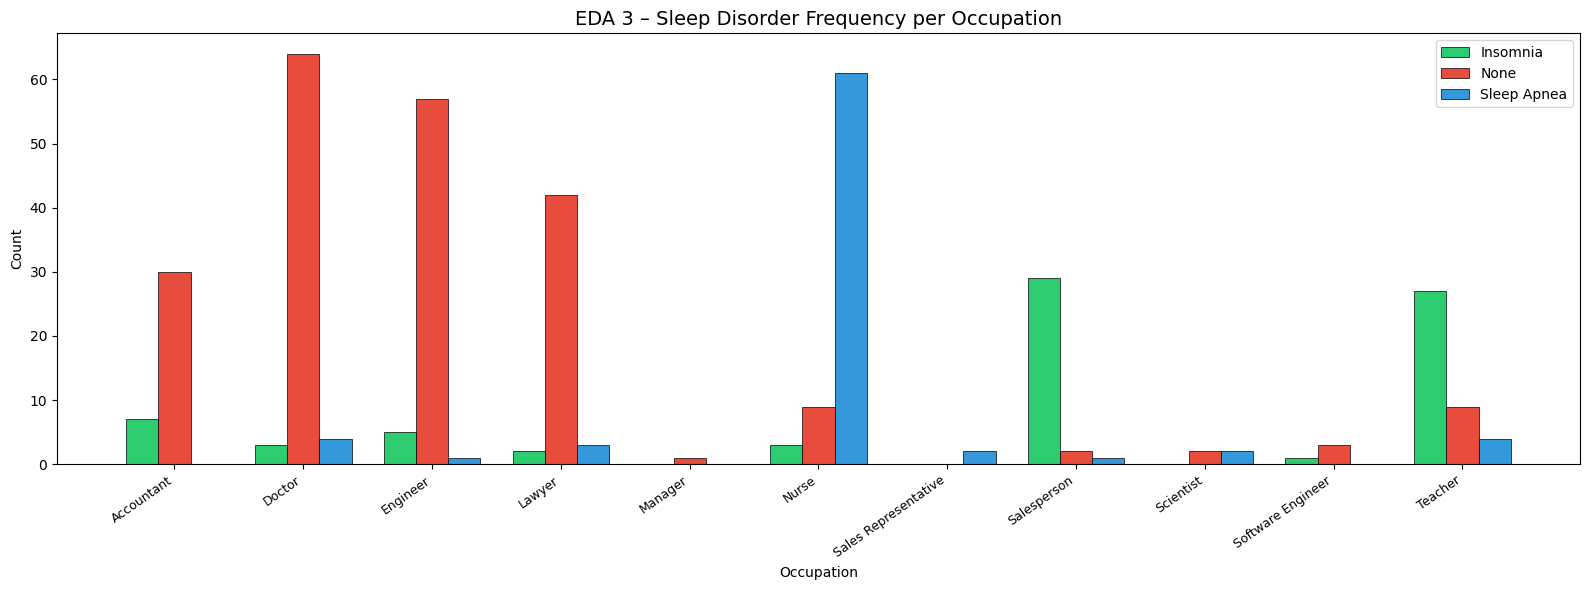

In [ ]:

import matplotlib.pyplot as plt, numpy as np


df_eda3 = df.dropna(subset=['Sleep Disorder', 'Occupation']).copy()

disorder_occ     = df_eda3.groupby(['Occupation', 'Sleep Disorder']).size().unstack(fill_value=0)
disorder_classes = disorder_occ.columns.tolist()
x     = np.arange(len(disorder_occ))
width = 0.25
colors_occ = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(16, 6))
for idx, (disorder, color) in enumerate(zip(disorder_classes, colors_occ)):
    ax.bar(x + idx*width, disorder_occ[disorder], width,
           label=disorder, color=color, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(disorder_occ.index, rotation=35, ha='right', fontsize=9)
ax.set_title('EDA 3 – Sleep Disorder Frequency per Occupation', fontsize=14)
ax.set_xlabel('Occupation'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()


##  Wearable Sensor Feature Statistics per Sleep Disorder Class




EDA 4 – Sensor Feature Statistics per Sleep Disorder Class
   Disorder                 Feature     Mean      Std    Min     Max  Count
   Insomnia              Heart Rate   70.468    4.949   65.0    85.0     77
   Insomnia          Sleep Duration    6.590    0.387    5.9     8.3     77
   Insomnia Physical Activity Level   46.818   11.752   30.0    90.0     77
   Insomnia            Stress Level    5.870    1.463    3.0     8.0     77
   Insomnia             Daily Steps 5901.299 1000.328 3000.0 10000.0     77
       None              Heart Rate   69.018    2.658   65.0    77.0    219
       None          Sleep Duration    7.358    0.732    6.0     8.5    219
       None Physical Activity Level   57.950   20.930   30.0    90.0    219
       None            Stress Level    5.114    1.591    3.0     8.0    219
       None             Daily Steps 6852.968 1393.474 4200.0 10000.0    219
Sleep Apnea              Heart Rate   73.090    5.117   68.0    86.0     78
Sleep Apnea          Sleep Du

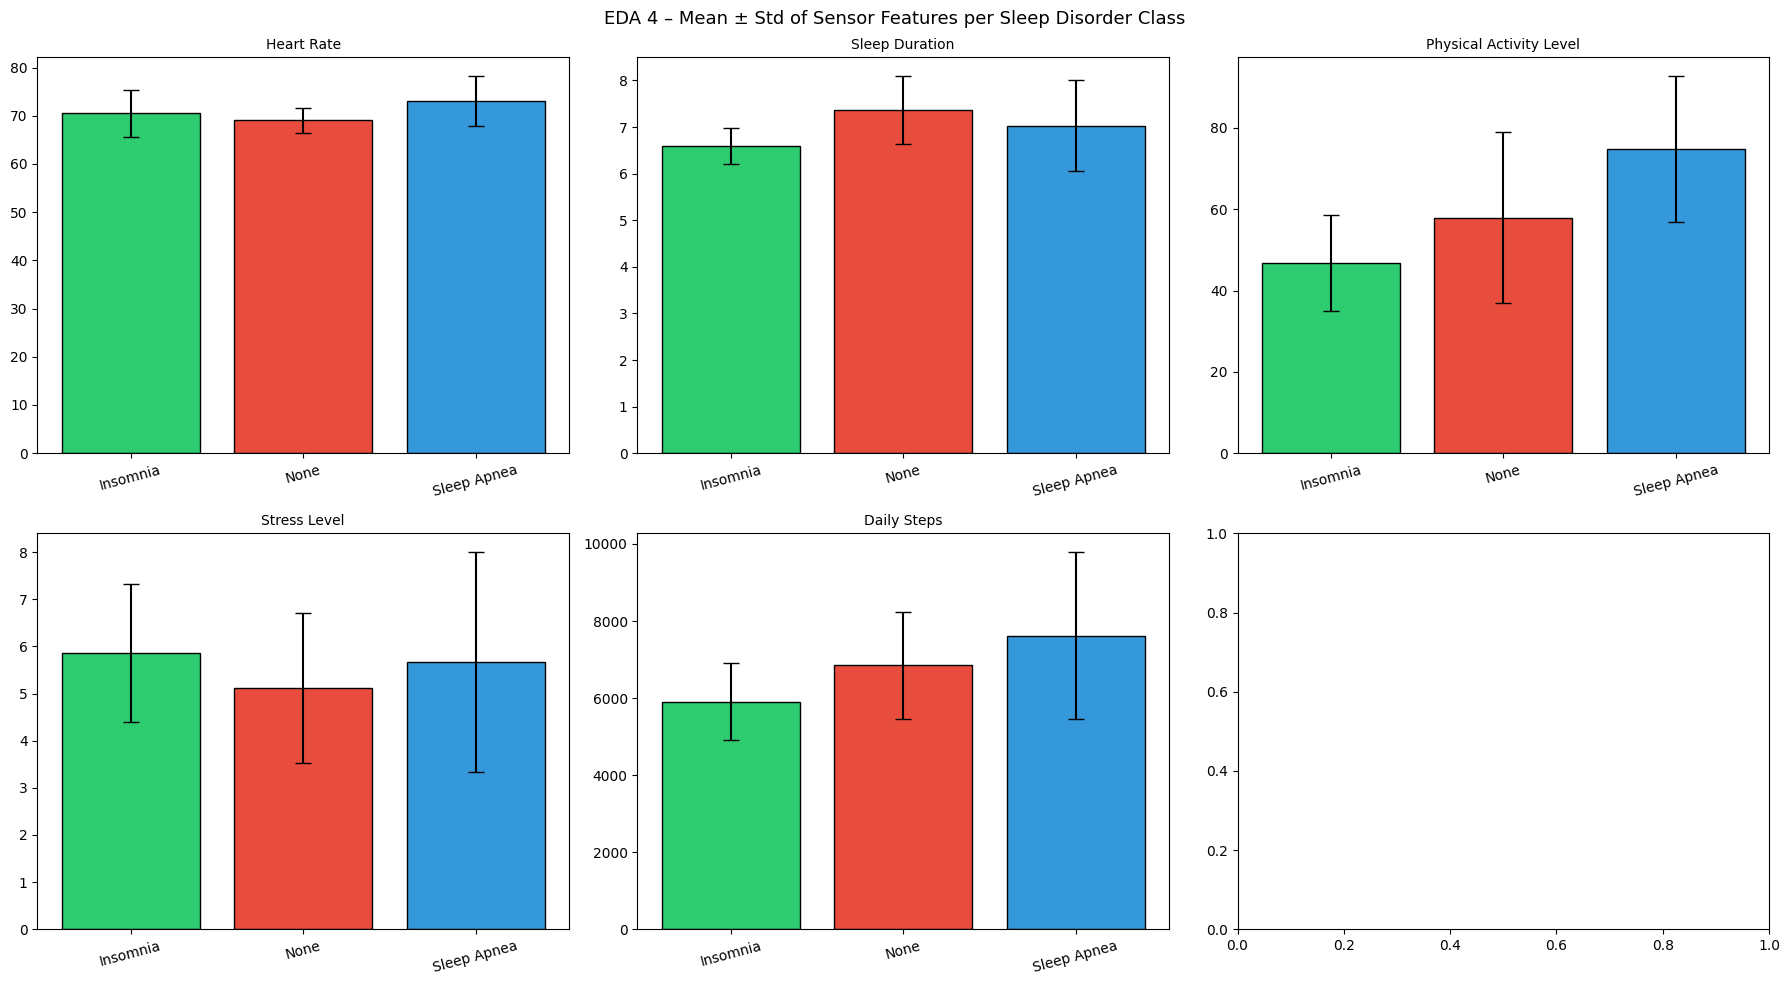

In [ ]:

import pandas as pd, numpy as np

sensor_feats = ['Heart Rate', 'Blood Oxygen Level', 'Sleep Duration',
                'Physical Activity Level', 'Stress Level', 'Daily Steps']

sensor_feats = [f for f in sensor_feats if f in df.columns]

df_eda4 = df.dropna(subset=['Sleep Disorder'] + sensor_feats).copy()

# Safe sort: drop NaN then sort
disorder_order = sorted(df_eda4['Sleep Disorder'].dropna().unique(), key=str)

rows = []
for disorder in disorder_order:
    sub = df_eda4[df_eda4['Sleep Disorder'] == disorder][sensor_feats]
    for feat in sensor_feats:
        rows.append({
            'Disorder': disorder,
            'Feature':  feat,
            'Mean':     round(sub[feat].mean(), 3),
            'Std':      round(sub[feat].std(),  3),
            'Min':      round(sub[feat].min(),  3),
            'Max':      round(sub[feat].max(),  3),
            'Count':    len(sub)
        })

stats_df = pd.DataFrame(rows)
print("EDA 4 – Sensor Feature Statistics per Sleep Disorder Class")
print(stats_df.to_string(index=False))

# Visualise mean ± std
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_stat = ['#2ecc71', '#e74c3c', '#3498db']
for ax, feat in zip(axes.ravel(), sensor_feats):
    means = [df_eda4[df_eda4['Sleep Disorder']==d][feat].mean() for d in disorder_order]
    stds  = [df_eda4[df_eda4['Sleep Disorder']==d][feat].std()  for d in disorder_order]
    ax.bar(disorder_order, means, yerr=stds,
           color=colors_stat[:len(disorder_order)], edgecolor='black', capsize=6)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('EDA 4 – Mean ± Std of Sensor Features per Sleep Disorder Class', fontsize=13)
plt.tight_layout(); plt.show()


##  Sample Count Heatmap (Sleep Disorder × Age Group)



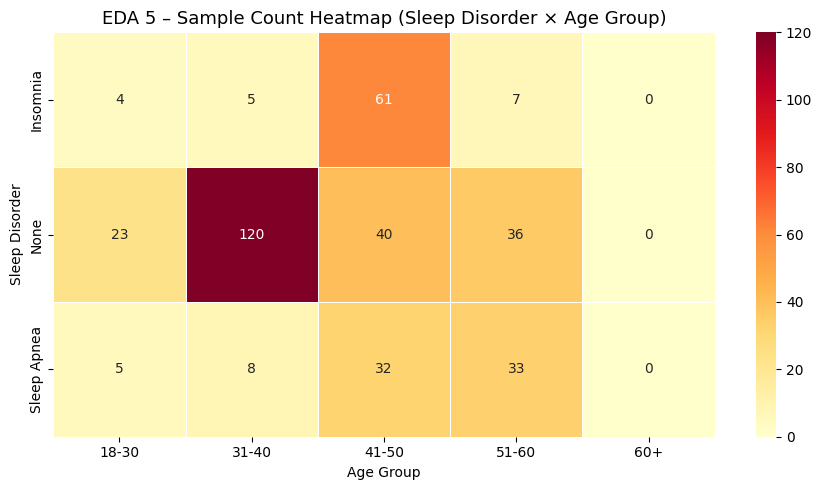

In [ ]:

import matplotlib.pyplot as plt, numpy as np, seaborn as sns

df_eda5 = df.dropna(subset=['Sleep Disorder', 'Age']).copy()

df_eda5['Age Group'] = pd.cut(df_eda5['Age'], bins=[18,30,40,50,60,90],
                               labels=['18-30','31-40','41-50','51-60','60+'])
age_groups    = ['18-30','31-40','41-50','51-60','60+']


disorder_list = sorted(df_eda5['Sleep Disorder'].dropna().unique(), key=str)

matrix = np.array([
    [df_eda5[(df_eda5['Sleep Disorder']==d) & (df_eda5['Age Group']==ag)].shape[0]
     for ag in age_groups]
    for d in disorder_list
])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=age_groups, yticklabels=disorder_list,
            linewidths=0.5, ax=ax)
ax.set_title('EDA 5 – Sample Count Heatmap (Sleep Disorder × Age Group)', fontsize=13)
ax.set_xlabel('Age Group'); ax.set_ylabel('Sleep Disorder')
plt.tight_layout(); plt.show()


## Visualising Wearable Sensor Signal Samples from the Dataset

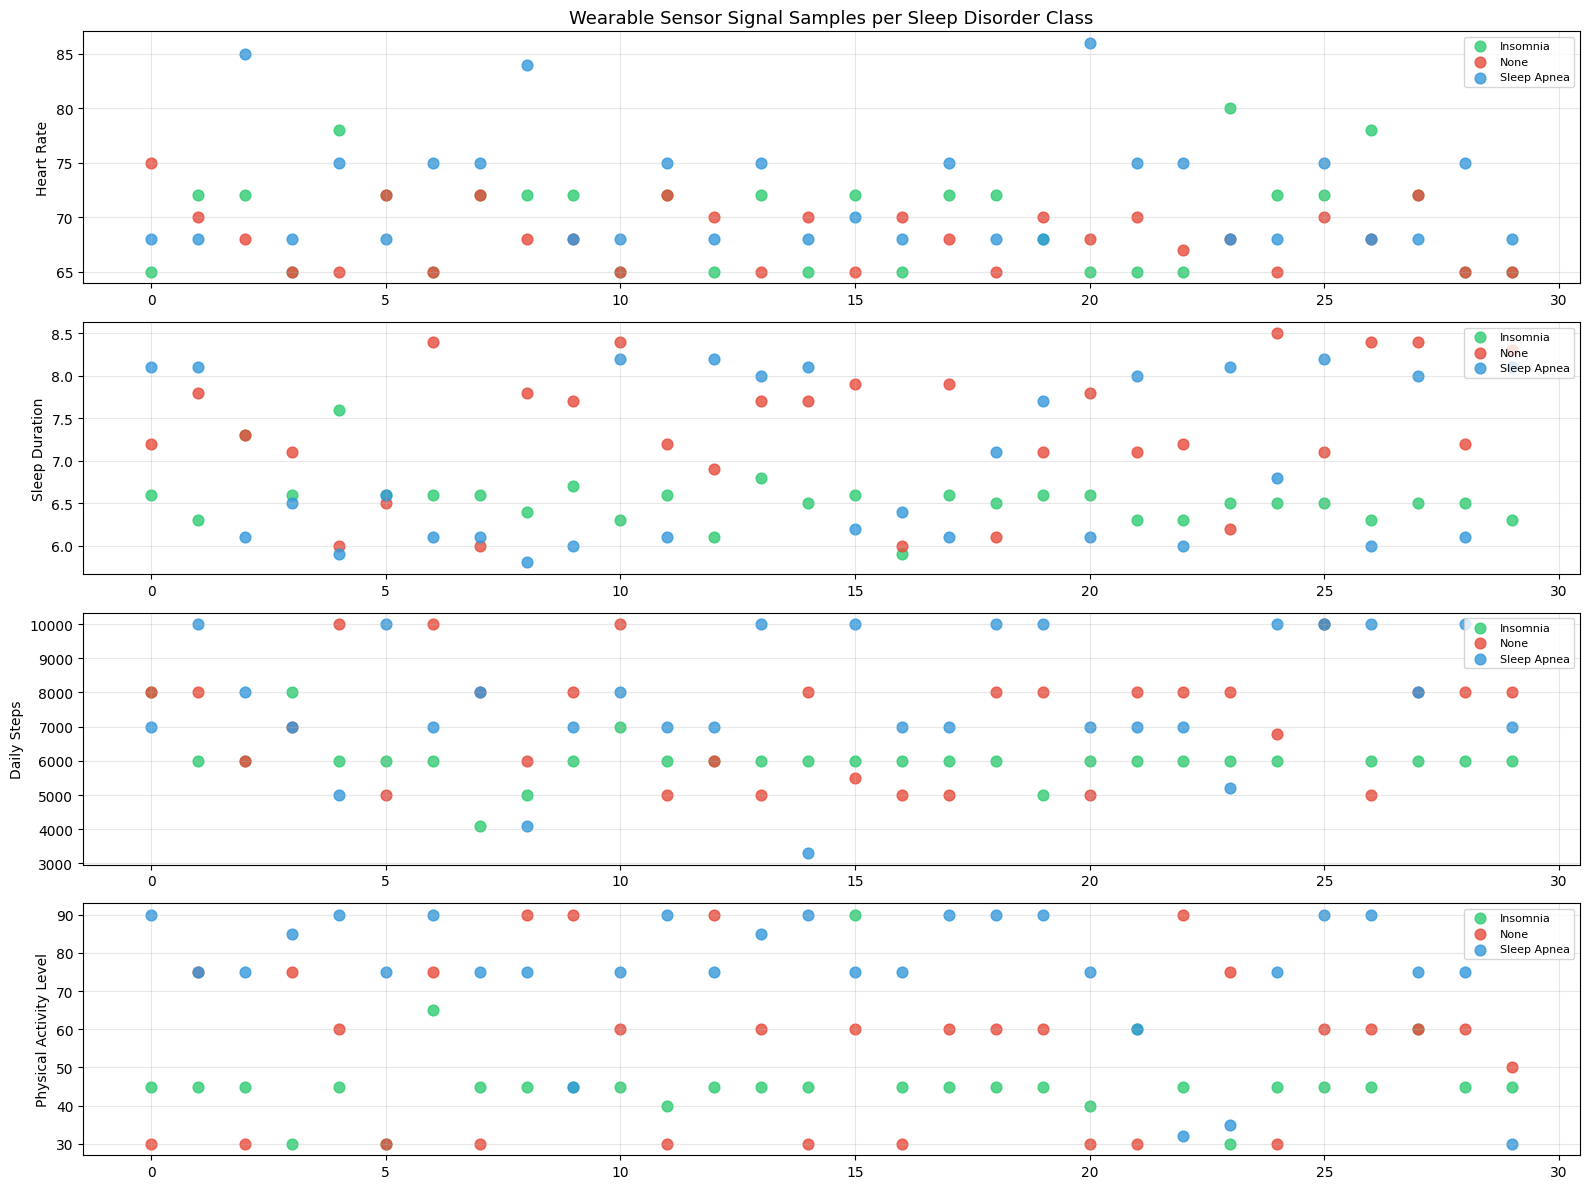

In [ ]:

def visualize_sensor_samples(n_samples=30):
    sensor_cols = [c for c in ['Heart Rate', 'Blood Oxygen Level',
                                'Sleep Duration', 'Daily Steps',
                                'Physical Activity Level', 'Stress Level']
                   if c in df.columns][:4]

    
    df_vis       = df.dropna(subset=['Sleep Disorder']).copy()
    disorder_list = sorted(df_vis['Sleep Disorder'].unique(), key=str)
    colors_vis    = ['#2ecc71', '#e74c3c', '#3498db']

    fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(16, 12), sharex=False)
    if len(sensor_cols) == 1:
        axes = [axes]

    for ax, feat in zip(axes, sensor_cols):
        for disorder, color in zip(disorder_list, colors_vis):
            subset  = df_vis[df_vis['Sleep Disorder'] == disorder][feat].values
            n_pick  = min(n_samples, len(subset))
            indices = np.random.choice(len(subset), size=n_pick, replace=False)
            ax.scatter(range(n_pick), subset[indices],
                       label=disorder, color=color, s=60, alpha=0.8)
        ax.set_ylabel(feat, fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[0].set_title('Wearable Sensor Signal Samples per Sleep Disorder Class',
                      fontsize=13)
    plt.tight_layout(); plt.show()

visualize_sensor_samples(n_samples=30)


# Data Preprocessing
<hr>

## Extracting and engineering features from wearable sensor data


In [ ]:

df_proc = df.dropna(subset=['Sleep Disorder']).copy()  
df_proc = df_proc.reset_index(drop=True)


le_gender = LabelEncoder()
df_proc['Gender_enc'] = le_gender.fit_transform(df_proc['Gender'])

le_bmi = LabelEncoder()
df_proc['BMI_enc'] = le_bmi.fit_transform(df_proc['BMI Category'])


if 'Blood Pressure' in df_proc.columns:
    try:
        bp_split = df_proc['Blood Pressure'].str.split('/', expand=True).astype(float)
        df_proc['BP_Systolic']  = bp_split[0]
        df_proc['BP_Diastolic'] = bp_split[1]
        df_proc['Pulse_Pressure'] = df_proc['BP_Systolic'] - df_proc['BP_Diastolic']
    except Exception:
        df_proc['BP_Systolic']    = 120.0
        df_proc['BP_Diastolic']   = 80.0
        df_proc['Pulse_Pressure'] = 40.0


if 'Sleep Duration' in df_proc.columns:
    df_proc['Sleep_Efficiency_Proxy'] = (df_proc['Sleep Duration'] /
                                          df_proc['Sleep Duration'].max())


if 'Physical Activity Level' in df_proc.columns and 'Stress Level' in df_proc.columns:
    df_proc['Activity_Stress_Ratio'] = (df_proc['Physical Activity Level'] /
                                          (df_proc['Stress Level'] + 1e-6))


if 'Daily Steps' in df_proc.columns and 'Physical Activity Level' in df_proc.columns:
    df_proc['Steps_per_Activity'] = (df_proc['Daily Steps'] /
                                      (df_proc['Physical Activity Level'] + 1e-6))

print(f"Records after dropping NaN Sleep Disorder rows: {len(df_proc)}")
print(f"Features after engineering: {df_proc.shape[1]}")
df_proc.head(3)


Records after dropping NaN Sleep Disorder rows: 374
Features after engineering: 21


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,...,Daily Steps,Sleep Disorder,Gender_enc,BMI_enc,BP_Systolic,BP_Diastolic,Pulse_Pressure,Sleep_Efficiency_Proxy,Activity_Stress_Ratio,Steps_per_Activity
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,...,4200,None,1,3,126.0,83.0,43.0,0.717647,6.999999,99.999998
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,1,0,125.0,80.0,45.0,0.729412,7.499999,166.666664
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,1,0,125.0,80.0,45.0,0.729412,7.499999,166.666664


In [ ]:

FEATURE_COLS = [c for c in df_proc.select_dtypes(include=[np.number]).columns
                if c not in ['Person ID'] and 'Age Group' not in c]
print(f"Total numeric features for modelling: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Total numeric features for modelling: 15
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_enc', 'BMI_enc', 'BP_Systolic', 'BP_Diastolic', 'Pulse_Pressure', 'Sleep_Efficiency_Proxy', 'Activity_Stress_Ratio', 'Steps_per_Activity']


**The features above need to be reshaped into 3D sequences (samples, timesteps, features) before being fed into the LSTM model, as LSTMs expect temporal input.**

In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical


le_target = LabelEncoder()
df_proc['label'] = le_target.fit_transform(df_proc['Sleep Disorder'])
CLASS_NAMES = list(le_target.classes_)
N_CLASSES   = len(CLASS_NAMES)
print("Encoded classes:", {i: c for i, c in enumerate(CLASS_NAMES)})

X = df_proc[FEATURE_COLS].values.astype(np.float32)
y = df_proc['label'].values


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train_2d, X_val, y_train_raw, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)


scaler = StandardScaler()
X_train_2d = scaler.fit_transform(X_train_2d)
X_val       = scaler.transform(X_val)
X_test      = scaler.transform(X_test)

# SMOTE on 2D training set only
smote = SMOTE(random_state=42)
X_train_2d, y_train_raw = smote.fit_resample(X_train_2d, y_train_raw)


TIMESTEPS = 1
X_train = X_train_2d.reshape(-1, TIMESTEPS, X_train_2d.shape[1])
X_val   = X_val.reshape(-1, TIMESTEPS, X_val.shape[1])
X_test  = X_test.reshape(-1, TIMESTEPS, X_test.shape[1])


y_train = to_categorical(y_train_raw, num_classes=N_CLASSES)
y_val   = to_categorical(y_val,       num_classes=N_CLASSES)
y_test  = to_categorical(y_test,      num_classes=N_CLASSES)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"Sequence shape fed to LSTM: {X_train.shape[1:]}")


Encoded classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

X_train: (459, 1, 15)  y_train: (459, 3)
X_val  : (56, 1, 15)    y_val  : (56, 3)
X_test : (57, 1, 15)   y_test : (57, 3)
Sequence shape fed to LSTM: (1, 15)


##  Normalisation Verification



In [ ]:

for name, arr in [('X_train (3D)', X_train), ('X_val (3D)', X_val), ('X_test (3D)', X_test)]:
    flat = arr.reshape(-1, arr.shape[-1])
    print(f"{name}: mean≈{flat.mean():.4f}  std≈{flat.std():.4f}  "
          f"min={flat.min():.3f}  max={flat.max():.3f}  "
          f"shape={arr.shape}")


X_train (3D): mean≈0.0663  std≈1.0162  min=-2.972  max=4.576  shape=(459, 1, 15)
X_val (3D): mean≈0.0722  std≈1.0094  min=-2.216  max=4.576  shape=(56, 1, 15)
X_test (3D): mean≈0.0073  std≈1.0362  min=-2.972  max=4.576  shape=(57, 1, 15)


## Class Balance After SMOTE (Bar Chart per Split)



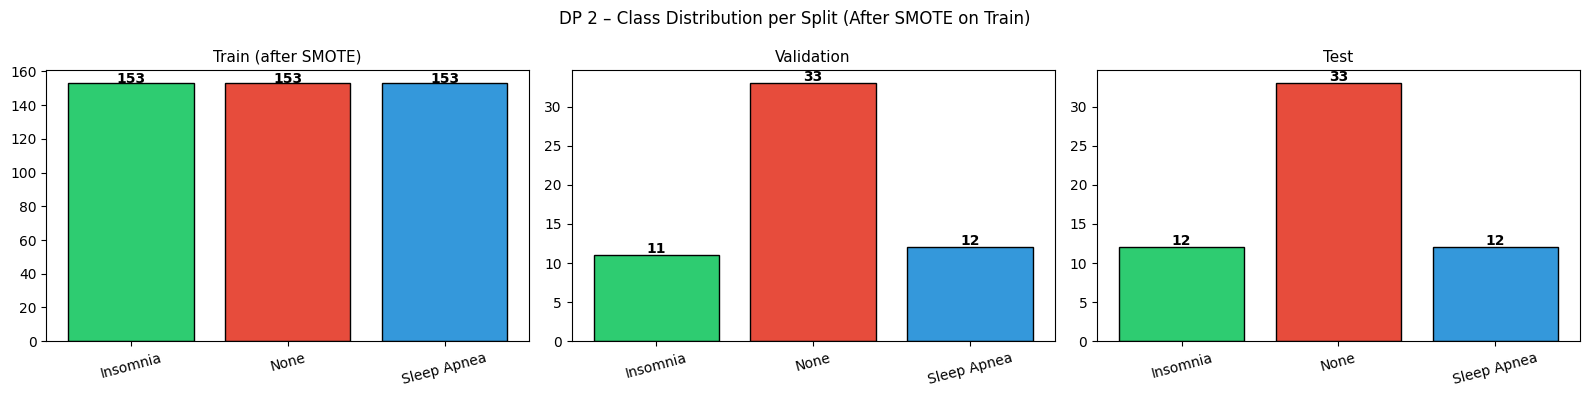

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_dp2 = ['#2ecc71', '#e74c3c', '#3498db']
for ax, (name, y_arr) in zip(axes, [
        ('Train (after SMOTE)', y_train),
        ('Validation', y_val),
        ('Test', y_test)]):
    y_idx = np.argmax(y_arr, axis=1)
    unique, counts = np.unique(y_idx, return_counts=True)
    ax.bar([CLASS_NAMES[u] for u in unique], counts,
           color=[colors_dp2[u] for u in unique], edgecolor='black')
    ax.set_title(f'{name}', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    for i, (u, c) in enumerate(zip(unique, counts)):
        ax.text(i, c + 0.3, str(c), ha='center', fontsize=10, fontweight='bold')
plt.suptitle('DP 2 – Class Distribution per Split (After SMOTE on Train)', fontsize=12)
plt.tight_layout(); plt.show()


## Feature Correlation Matrix



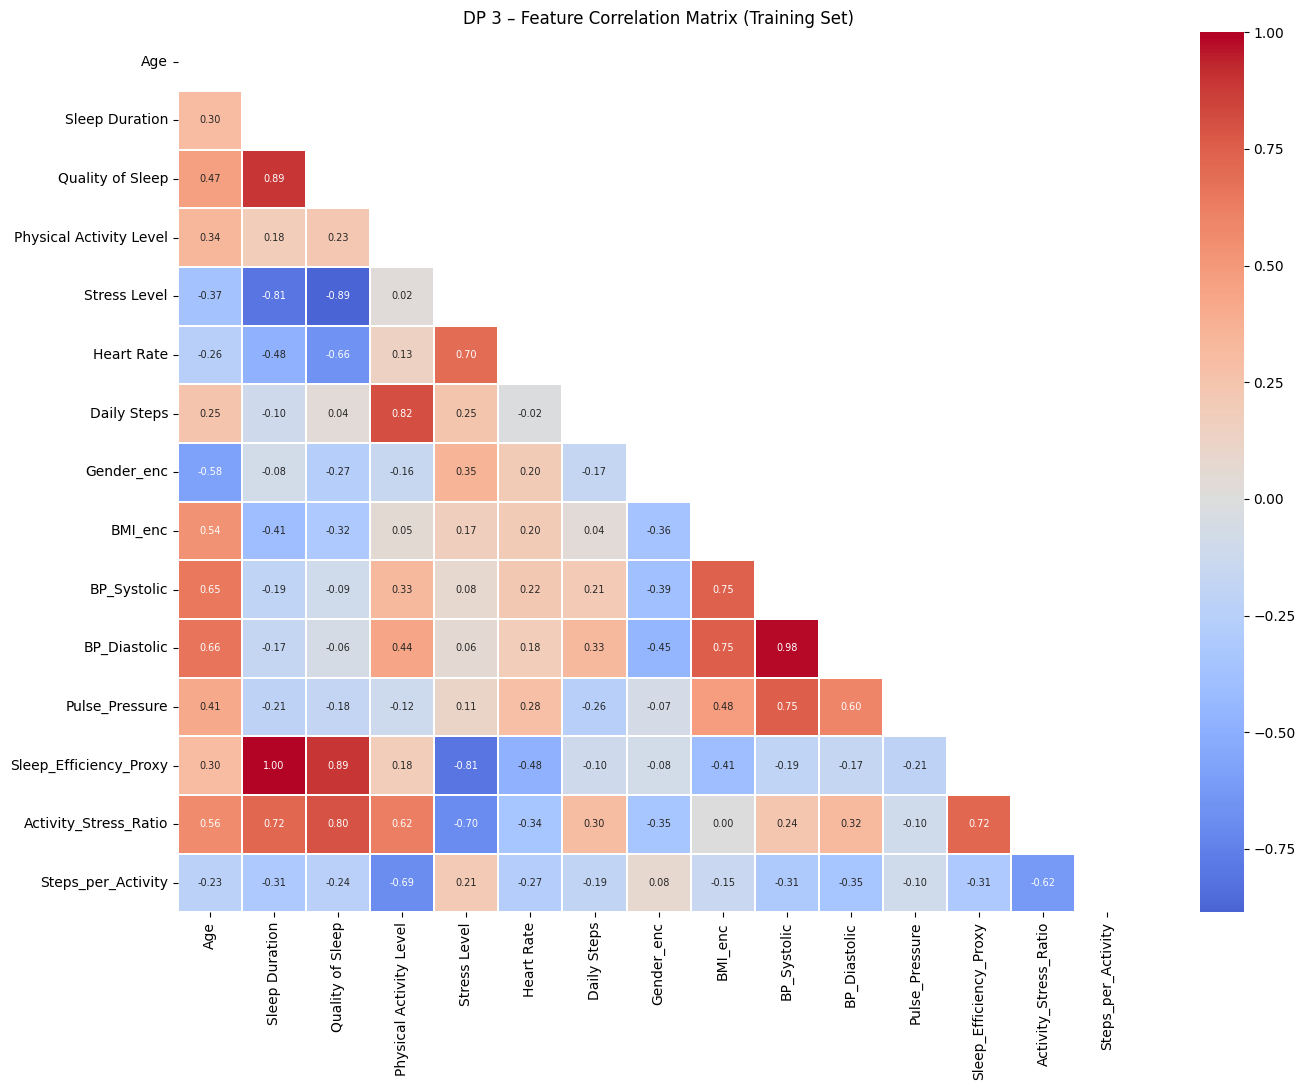

High-correlation pairs (|r|>0.9): [('Sleep Duration', 'Sleep_Efficiency_Proxy'), ('BP_Systolic', 'BP_Diastolic')]


In [ ]:

corr_df = pd.DataFrame(X_train.reshape(-1, X_train.shape[-1]),
                        columns=FEATURE_COLS).corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('DP 3 – Feature Correlation Matrix (Training Set)', fontsize=12)
plt.tight_layout(); plt.show()

high_corr = [(corr_df.columns[i], corr_df.columns[j])
             for i in range(len(corr_df))
             for j in range(i+1, len(corr_df))
             if abs(corr_df.iloc[i,j]) > 0.9]
print(f"High-correlation pairs (|r|>0.9): "
      f"{high_corr if high_corr else 'None found ✓'}")


## Data Processing 4 – LSTM Input Shape & Sequence Verification



In [ ]:

print("LSTM Input Tensor Shapes:")
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"  {name}: {arr.shape}  "
          f"→ ({arr.shape[0]} samples, {arr.shape[1]} timesteps, "
          f"{arr.shape[2]} features)")

print("\nOne-Hot Label Verification:")
for name, y_arr in [('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    row_sums  = y_arr.sum(axis=1)
    is_binary = np.all((y_arr == 0) | (y_arr == 1))
    is_sumone = np.allclose(row_sums, 1)
    print(f"  {name}: shape={y_arr.shape}  "
          f"one-hot_valid={is_binary and is_sumone}  "
          f"n_classes={y_arr.shape[1]}")


LSTM Input Tensor Shapes:
  X_train: (459, 1, 15)  → (459 samples, 1 timesteps, 15 features)
  X_val: (56, 1, 15)  → (56 samples, 1 timesteps, 15 features)
  X_test: (57, 1, 15)  → (57 samples, 1 timesteps, 15 features)

One-Hot Label Verification:
  y_train: shape=(459, 3)  one-hot_valid=True  n_classes=3
  y_val: shape=(56, 3)  one-hot_valid=True  n_classes=3
  y_test: shape=(57, 3)  one-hot_valid=True  n_classes=3


## Data Processing 5 – Train / Val / Test Shape & Memory Report


In [ ]:

for name, X_arr, y_arr in [('Train', X_train, y_train),
                             ('Val',   X_val,   y_val),
                             ('Test',  X_test,  y_test)]:
    mb_x = X_arr.nbytes / (1024**2)
    mb_y = y_arr.nbytes / (1024**2)
    print(f"{name:6s}: X={X_arr.shape}  y={y_arr.shape}  "
          f"dtype={X_arr.dtype}  X_mem≈{mb_x:.3f} MB  y_mem≈{mb_y:.3f} MB")
print(f"\nTotal input features per timestep : {X_train.shape[2]}")
print(f"LSTM sequence length (timesteps)  : {X_train.shape[1]}")


Train : X=(459, 1, 15)  y=(459, 3)  dtype=float32  X_mem≈0.026 MB  y_mem≈0.011 MB
Val   : X=(56, 1, 15)  y=(56, 3)  dtype=float32  X_mem≈0.003 MB  y_mem≈0.001 MB
Test  : X=(57, 1, 15)  y=(57, 3)  dtype=float32  X_mem≈0.003 MB  y_mem≈0.001 MB

Total input features per timestep : 15
LSTM sequence length (timesteps)  : 1
